In [1]:
!pip install optuna # TODO: Move this to requirements.txt and remove from notebook

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
import os
import dotenv
import sklearn
from sqlalchemy import create_engine
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

dotenv.load_dotenv()

True

# Fast ML Hyperparameter tuning on IRIS data Using Optuna (with MLflow visualizations)

When training ML models, the choice of hyperparameters strongly influences the performance of the model. While they are not the only factor, they can significantly impact both convergence and generalization.

Tuning hyperparameters takes a lot of time, and manually doing this requires substantial effort. This is especially true because changing one parameter can modify the influence of another hyperparameter, so it is not a trivial task of tuning each hyperparameter independently. For example, higher regularization may require a lower learning rate for more stable optimization. A more complex model may require stronger regularization to avoid overfitting, but at the same time, a very small learning rate on a complex model can make learning too slow.

Optuna is an MIT-licensed open source library (which allows commercial use) that automatically searches for optimal hyperparameters for ML models (e.g. sklearn, PyTorch, TensorFlow). It works by defining ranges of values for hyperparameters and a performance metric to be either maximized or minimized. Based on this, Optuna efficiently explores the search space to find well-performing configurations. Below we provide a brief explanation of how it works under the hood.

In this notebook, we will not only address a practical way to use Optuna, but also leverage its distributed optimization capabilities using a shared database. In particular, we will connect Optuna to IRIS DB tables to run concurrent processes that coordinate through the same study. This allows us to efficiently train and tune a complex model with many hyperparameters, such as a LightGBM model.

We will also take into account important considerations to avoid overfitting, such as k-fold cross-validation and proper evaluation strategies.

For this purpose, we will use a sample dataset (california_housing, commonly used in ML examples) to populate IRIS tables, and then leverage Optuna's distributed tuning to run multiple coordinated processes and accelerate the hyperparameter search.

Note: In this exercise, you will need an existing IRIS instance that you can connect to. I am using the one created with Docker by running the docker-compose file from this [repo](https://github.com/JorgeIvanJH/IRIS_and_MLflow-Continuous-Training-Pipeline). I am also using the environment variables and requirements.txt from that repository, together with Python 3.12.

## Quick Intro to Optuna

[Optuna](https://optuna.org/) is a hyperparameter optimization framework that speeds up hyperparameter tuning by training multiple instances of an ML model with different hyperparameters. It achieves this by:

- Exploring which hyperparameters are more relevant for a given model and dataset, and focusing the search on promising regions of the space
- Choosing the most promising regions in the search space using efficient sampling strategies (e.g. TPE)
- Early stopping unpromising hyperparameter combinations through pruning strategies
- Supporting distributed and coordinated optimization to scale up training across multiple processes using the same study
- Providing visualization tools to better understand the search space and the importance of different hyperparameters

For a richer intro to optuna see this [video](https://www.youtube.com/watch?v=P6NwZVl8ttc)


### Optuna to Avoid Endless Hyperparameter Tuning:

A practical approach to efficiently find good hyperparameters is:

1. Tune once to get baseline parameters and a reasonable range where each hyperparameter could vary (in a CT pipeline this would be done in the experimentation phase)
2. Tune again using a more focused search strategy with Optuna (in a CT pipeline this can be repeated when there is data shift and/or model degradation)

Note: Hyperparameter tuning must be done with an appropriate validation setup. Otherwise, you will only find the best overfitting configuration, not one that truly generalizes to the underlying patterns in the data.

## Loading Dataset

Below cell connects to an IRIS instance, loads SKlearn's associated fetch_california_housing dataset, and uploads it to a table in IRIS with schema "OptunaTuning" and tablename "CaliforniaHousing".

In [3]:


# Connection String to Existing IRIS Database
server = os.getenv("IRIS_SERVER")
port = os.getenv("IRIS_PORT") # Standard InterSystems superserver port
namespace = os.getenv("IRIS_NAMESPACE")
username = os.getenv("IRIS_USERNAME")
password = os.getenv("IRIS_PASSWORD")
engine = create_engine(f"iris://{username}:{password}@{server}:{port}/{namespace}")

# Load California Housing Dataset
X,y = sklearn.datasets.fetch_california_housing(return_X_y=True,as_frame=True)
X.columns = [col.replace(" ", "_") for col in X.columns]
y.name = "median_house_value"
df = X.copy()
df[y.name] = y
status = df.to_sql("CaliforniaHousing", engine, schema="OptunaTuning", if_exists='replace', index=False)
if status is not None:
    print(f"Loaded Table into IRIS database.")

Loaded Table into IRIS database.


## Model Definition and Training

### Choosing the right K-fold Split

It is important to choose the best suited K-fold Strategy, and this depends on the task (regression or classification), class imbalance, if order matters (such as in time-series), and if there are groups within the data. Sor the sake of simplicity we chose for our task using the following decision rules:

```python
if time_order_matters:
    use TimeSeriesSplit   # no shuffle equivalent
else:
    if groups_exist:
        if classification and classes_are_imbalanced:
            use StratifiedGroupKFold   # (no shuffle equivalent)
        else:
            use GroupKFold             # → or GroupShuffleSplit
    else:
        if classification and classes_are_imbalanced:
            use StratifiedKFold        # → or StratifiedShuffleSplit
        else:
            use KFold                  # → or ShuffleSplit
```

Refer to this [summay](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py) of the options available in SKlearn for further guidance.

In [4]:
crossvalstrategy = KFold(n_splits=3, shuffle=True, random_state=42)

### Hyperparemeter Search with Optuna

After deciding on our model (LightGBM) which should be made with a reasonable justification on the type of problem and data at hand. We have chosen LightGBM beforehand. For our model we will identify the most relevant hyperparameters that are relevant to tweak.

The cells in this section would be run multiple times until until satisfying the performance metrics defined WHICH SHOULD ALWAYS USE CROSS VALIDATION. We have highlighted the variables of interest that are recommended to tweak every time you want to re run a new study.

The process done here is basically running studies with a certain number of trials, then watching at the hyperparameter importance and seasrch space plots, along with the achieved best performance metric and parameters found and then reruning studies with varying ranges for each hyperparameter


It is worth mentioning that for all our trials we have to use a sensible metric. In our case, which is a regression, we will use mean squared error, which we want to minimize. and this metric is evaluated using the already defined cross-validation strategy.

NOTE that for the study we are reusing the same cross validation strategy and performance metric defined above

NOTE: When pointing to the same database (storage=storage_url), Optuna coordinates simultaneous searches over the search space. Optuna stores the studies information on that database

In [8]:
1

1

TODO: Explain how it would work on a script for multiprocess

In [10]:
NUM_TRIALS = 20 # Tweak

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

def objective(trial):
    param = {
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2,log=True), # Tweak
        "max_depth": trial.suggest_int("max_depth", 3, 50), # Tweak
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000), # Tweak
        "num_leaves": trial.suggest_categorical("num_leaves", [16, 31, 63, 127, 255]),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True), # Tweak
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255])
    }

    model = lgb.LGBMRegressor(**param)

    scores = cross_val_score(model, X, y, 
                            cv=crossvalstrategy, 
                            scoring=make_scorer(mean_squared_error), 
                            n_jobs=-1)
    return scores.mean()

storage_url = f"iris://{username}:{password}@{server}:{port}/{namespace}"

study = optuna.create_study(study_name="lightgbm_study_cpuv5", 
                            direction="minimize",
                            storage=storage_url,
                            load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(seed=42),)
study.optimize(objective, n_trials=NUM_TRIALS, show_progress_bar=True, n_jobs=1)
best_params = study.best_params
print(f"\nBest parameters: {best_params}")
print(f"\nBest performance: {study.best_value}")


[I 2026-05-08 16:29:53,288] A new study created in RDB with name: lightgbm_study_cpuv5


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-08 16:30:20,557] Trial 0 finished with value: 0.22124664870518 and parameters: {'learning_rate': 0.00727491708802781, 'max_depth': 48, 'n_estimators': 746, 'num_leaves': 255, 'lambda_l2': 0.002570603566117598, 'max_bin': 255}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-08 16:30:24,235] Trial 1 finished with value: 0.2059125561807643 and parameters: {'learning_rate': 0.0823143373099555, 'max_depth': 13, 'n_estimators': 222, 'num_leaves': 63, 'lambda_l2': 0.0032112643094417484, 'max_bin': 255}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-08 16:30:29,069] Trial 2 finished with value: 0.25714400572802726 and parameters: {'learning_rate': 0.01120548642504815, 'max_depth': 40, 'n_estimators': 239, 'num_leaves': 127, 'lambda_l2': 3.850031979199519e-08, 'max_bin': 127}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-08 16:30:36,408] Trial 3 finished with value: 0.26413921215873515 and parameters: {'learning_rate': 0.0050225633119947675, 'max_dept

Below we see the top 5 combinations that gave the best performances and some basic distribution of the best 10 hyperparameter combinations found in the study to help guide future studies

In [ ]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values("value")
trials_df = trials_df.loc[:, trials_df.columns.str.contains("params|value")]
top_trials_df = trials_df.head(10)

display(top_trials_df)
display(top_trials_df.describe())

,value,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_n_estimators,params_num_leaves
17,0.204993,1.190268e-01,0.046085,255,49,604,31
13,0.206883,2.505083e-05,0.017559,127,10,901,63
14,0.208137,1.000347e-01,0.025850,127,20,843,31
18,0.209573,5.986071e-08,0.024192,255,28,384,127
15,0.212673,8.374891e-04,0.044179,127,50,216,63


,value,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_n_estimators,params_num_leaves
count,13.000000,1.300000e+01,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.233632,4.485239e-01,0.029674,166.384615,28.538462,565.230769,81.538462
std,0.033330,1.056593e+00,0.023091,76.347384,18.159549,316.947986,64.527275
min,0.204993,1.572097e-08,0.002799,63.000000,6.000000,65.000000,16.000000
25%,0.209573,2.505083e-05,0.013498,127.000000,10.000000,299.000000,31.000000
50%,0.213817,1.162541e-03,0.024192,127.000000,28.000000,577.000000,63.000000
75%,0.250775,1.000347e-01,0.046085,255.000000,48.000000,843.000000,127.000000
max,0.296938,3.297897e+00,0.074502,255.000000,50.000000,990.000000,255.000000


After a first broad search we can use the completed study to get a score of the most important parameters to focus on, and make a more grained search over those in a sensible range which we should have identified with the first study.

The below cell gets a score for the importance of all parameters in a scale from 0 to 1 all parameters. This function will give a score for all the parameters included in the study

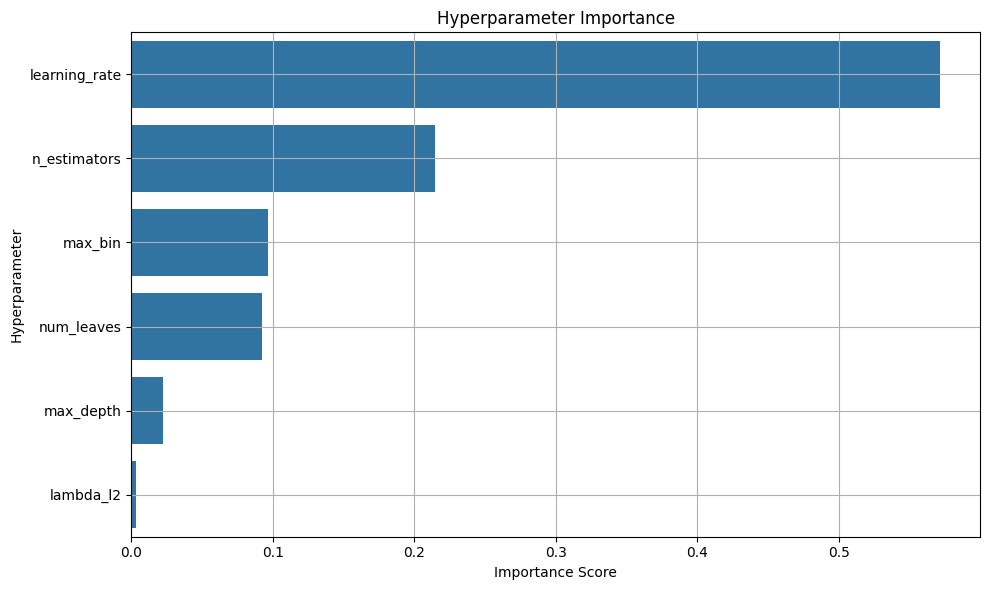

In [ ]:
param_importance_dict = optuna.importance.get_param_importances(study)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=list(param_importance_dict.values()), y=list(param_importance_dict.keys()))
plt.xlabel('Importance Score')
plt.ylabel('Hyperparameter')
plt.title('Hyperparameter Importance')
plt.tight_layout()
plt.grid()
plt.show()

By Looking at the plot above we notice which are the most relevant hyperparameters. Next we decide how many of the top parameters we want to compare. We will choose only the 2 most important.

With the plot below we not only see the search space for these 2 most important parameters, but also a sensible range to explore, which we can use to further explore.

C:\Users\jjaramil\AppData\Local\Temp\ipykernel_8504\1164999211.py:3: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=best2params)


<Axes: title={'center': 'Contour Plot'}, xlabel='learning_rate', ylabel='n_estimators'>

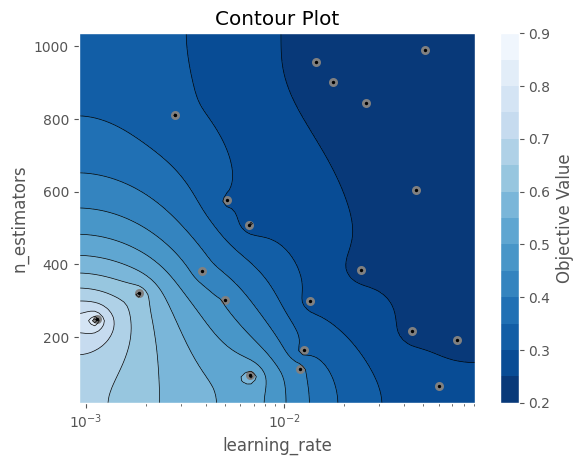

In [ ]:
numparamstocompare = 2
best2params = [k for k, v in sorted(param_importance_dict.items(), key=lambda x: x[1])[-numparamstocompare:]]
optuna.visualization.matplotlib.plot_contour(study, params=best2params)

We can leverage these plots to guide new ranges to further explore hyperparameters